In [1]:
import os
from PIL import Image, ImageOps
import numpy as np
from pathlib import Path
import re

# Get all image files from Phase1 directory
image_dir = Path('Phase1')
image_files = sorted(image_dir.glob('*.jpg'))

# Dictionary to track counts for each label
label_counts = {}

# Lists to store images and labels
images = []
y = []

# Load images and create labels
for img_path in image_files:
    # Extract label name from filename (everything before the last underscore and number)
    filename = img_path.stem  # Get filename without extension
    # Find the label name (everything before the last underscore)
    match = re.match(r'^(.+?)_\d+$', filename)
    if match:
        label_name = match.group(1).lower()  # Convert to lowercase
        
        # Initialize counter for this label if not seen before
        if label_name not in label_counts:
            label_counts[label_name] = 0
        
        label_counts[label_name] += 1
        
        # Use just the label name (no underscore and index)
        label = label_name
        
        # Load image
        img = Image.open(img_path)
        images.append(img)
        y.append(label)

print(f"Loaded {len(images)} images")
print(f"Unique label types: {list(label_counts.keys())}")
print(f"Label counts: {label_counts}")
print(f"\nFirst few labels: {y[:5]}")



Loaded 1230 images
Unique label types: ['closed_hand', 'open_hand', 'point_left', 'point_right', 'thumbs_down', 'thumbs_up']
Label counts: {'closed_hand': 186, 'open_hand': 186, 'point_left': 220, 'point_right': 226, 'thumbs_down': 200, 'thumbs_up': 212}

First few labels: ['closed_hand', 'closed_hand', 'closed_hand', 'closed_hand', 'closed_hand']


In [2]:
import matplotlib.pyplot as plt

def plot_image(image):
    # Convert PIL image to numpy array if needed
    if isinstance(image, Image.Image):
        image = np.array(image)
    
    # Determine if grayscale or color
    if len(image.shape) == 2 or image.shape[2] == 1:
        # Grayscale image
        plt.imshow(image, cmap='gray')
    else:
        # Color image
        plt.imshow(image)
    plt.axis('off')
    plt.show()

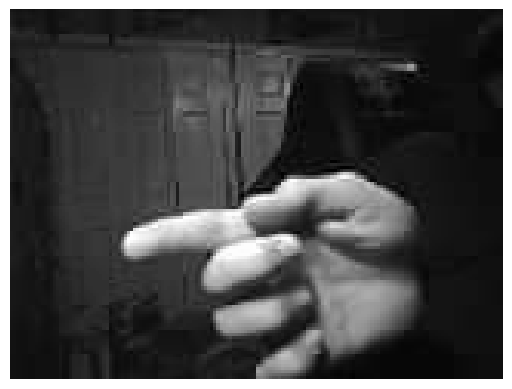

In [3]:
grayscale_images = [ImageOps.grayscale(img) for img in images]
plot_image(grayscale_images[700])

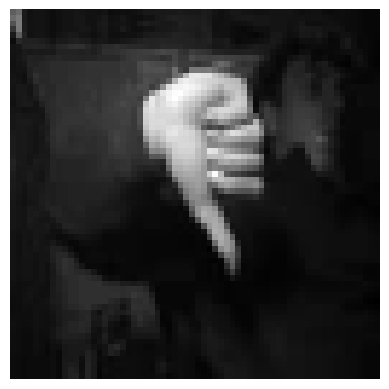

In [4]:
smaller_grayscale_images = [ImageOps.grayscale(img.resize((64, 64))) for img in images]
plot_image(smaller_grayscale_images[1000])

In [5]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# CRITICAL: Split BEFORE preprocessing to avoid data leakage!
# Convert labels to numpy array for splitting
y_labels = np.array(y)

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

# Split the RAW images and labels FIRST (before any preprocessing)
images_train, images_test, y_train_encoded, y_test_encoded = train_test_split(
    images, y_encoded, 
    test_size=0.2, 
    random_state=42,
    shuffle=True,  # Shuffle to avoid temporal leakage from sorted filenames
    stratify=y_encoded  # Maintain class distribution in train/test
)

print(f"Train size: {len(images_train)}, Test size: {len(images_test)}")
print(f"Unique classes in train: {np.unique(y_train_encoded)}")
print(f"Unique classes in test: {np.unique(y_test_encoded)}")

# NOW process train and test sets SEPARATELY
def preprocess_images(img_list):
    """Process images: grayscale, resize, normalize"""
    processed = []
    for x in img_list:
        x = ImageOps.grayscale(x)
        x = x.resize((64, 64))
        x = np.array(x, dtype=np.float32) / 255.0  # normalize to [0, 1]
        processed.append(x)
    return np.stack(processed)

# Process train set
X_train = preprocess_images(images_train)
X_train = torch.from_numpy(X_train).unsqueeze(1)  # (N, 1, 64, 64)
y_train = torch.from_numpy(y_train_encoded).long()

# Process test set (using same preprocessing steps, but separate processing)
X_test = preprocess_images(images_test)
X_test = torch.from_numpy(X_test).unsqueeze(1)  # (N, 1, 64, 64)
y_test = torch.from_numpy(y_test_encoded).long()

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Create data loaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)


Train size: 984, Test size: 246
Unique classes in train: [0 1 2 3 4 5]
Unique classes in test: [0 1 2 3 4 5]

X_train shape: torch.Size([984, 1, 64, 64]), y_train shape: torch.Size([984])
X_test shape: torch.Size([246, 1, 64, 64]), y_test shape: torch.Size([246])


In [6]:

import torch.nn as nn
import torch.nn.functional as F

class HandNet100k(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 1x64x64 -> 32x32x32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 32x32x32 -> 64x16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 64x16x16 -> 128x16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # Reduce spatial dims to 1x1
            nn.AdaptiveAvgPool2d(1),
        )

        # Final classifier: 128 -> 6
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # B x 128
        return self.classifier(x)



# Instantiate model, loss, and optimizer
mod = HandNet100k()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mod.parameters(), lr=0.001)

# Fix: Use the correct DataLoader variable names
n_epochs = 10
mod.train()
for epoch in range(n_epochs):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = mod(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.4f}")

mod.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = mod(batch_X)
        _, predicted = outputs.max(1)
        correct += predicted.eq(batch_y).sum().item()
        total += batch_y.size(0)

print(f"Accuracy of the model on the {total} test images: {100 * correct / total:.2f}%")

Epoch 1/10, Loss: 1.3739
Epoch 2/10, Loss: 0.9143
Epoch 3/10, Loss: 0.5362
Epoch 4/10, Loss: 0.3176
Epoch 5/10, Loss: 0.1851
Epoch 6/10, Loss: 0.1319
Epoch 7/10, Loss: 0.0998
Epoch 8/10, Loss: 0.0669
Epoch 9/10, Loss: 0.0457
Epoch 10/10, Loss: 0.0398
Accuracy of the model on the 246 test images: 90.65%


In [7]:
# Save only the weights of the model (state_dict)
torch.save(mod.state_dict(), 'phase1_weights.pth')

# Print the size of the weights file
import os
weights_size = os.path.getsize('phase1_weights.pth')
print(f"Saved weights file 'phase1_weights.pth' size: {weights_size} bytes")

# Estimate the full model size for an ESP32:
# ESP32 typically requires quantized/int8 weights, but here we will show the PyTorch weight size
print(f"Estimated model size on ESP32 (without PyTorch overhead; weights only): {weights_size} bytes")



Saved weights file 'phase1_weights.pth' size: 385449 bytes
Estimated model size on ESP32 (without PyTorch overhead; weights only): 385449 bytes


In [8]:
# 1. Recreate and load weights
model = HandNet100k(num_classes=6)
state = torch.load("phase1_weights.pth", map_location="cpu")
model.load_state_dict(state)
model.eval()

# 2. Export to ONNX
dummy = torch.randn(1, 1, 64, 64)  # batch=1, 1x64x64 grayscale
onnx_path = "handnet_fp32.onnx"

torch.onnx.export(
    model,
    dummy,
    onnx_path,
    input_names=["input"],
    output_names=["logits"],
    opset_version=13,
    do_constant_folding=True,
)
print("Exported to", onnx_path)

W1128 10:57:32.645000 16840 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W1128 10:57:33.102000 16840 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `HandNet100k([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HandNet100k([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 122, in _partial_convert_version
    return onnx.version_conve

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 3 of general pattern rewrite rules.
Exported to handnet_fp32.onnx


In [9]:
from onnxruntime.quantization import quantize_dynamic, QuantType
import onnx

fp32_model = "handnet_fp32.onnx"
int8_model = "handnet_int8.onnx"

# Load ONNX and strip shape info problems
model = onnx.load(fp32_model)

# Disable shape inference by removing all ValueInfo protobufs
# (this prevents ORT from trying to reconcile shapes during quantization)
model.graph.value_info.clear()

onnx.save(model, "tmp_no_shinfo.onnx")

quantize_dynamic(
    model_input="tmp_no_shinfo.onnx",
    model_output=int8_model,
    weight_type=QuantType.QInt8,
    op_types_to_quantize=["Conv", "Gemm", "MatMul"],  # only ops that have weights
    use_external_data_format=False                    # keep everything in one file
)

print("Saved quantized model to", int8_model)


Saved quantized model to handnet_int8.onnx


In [10]:
import os
import numpy as np
import onnxruntime as ort
import torch

fp32_model_path = "handnet_fp32.onnx"
int8_model_path = "handnet_int8.onnx"

# 1. Print sizes
fp32_size = os.path.getsize(fp32_model_path)
int8_size = os.path.getsize(int8_model_path)
print(f"FP32 ONNX model size: {fp32_size} bytes")
print(f"INT8 ONNX model size: {int8_size} bytes")

# 2. Helper: evaluate an ONNX model that expects batch_size=1
def eval_onnx_batch1(model_path, test_loader):
    session = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name

    correct = 0
    total = 0

    for batch_X, batch_y in test_loader:
        # Loop over samples so each input has shape [1, 1, 64, 64]
        for x, y in zip(batch_X, batch_y):
            x_np = x.unsqueeze(0).cpu().numpy().astype(np.float32)  # [1, 1, 64, 64]
            logits = session.run([output_name], {input_name: x_np})[0]  # [1, 6]
            pred = int(logits.argmax(axis=1)[0])
            correct += int(pred == int(y.item()))
            total += 1

    acc = 100.0 * correct / total
    return acc

# 3. Try quantized model first (will fail due to ConvInteger kernel)
try:
    quant_session = ort.InferenceSession(int8_model_path, providers=["CPUExecutionProvider"])
    print("Quantized model loaded successfully, but this environment lacks ConvInteger kernels so we won't evaluate it here.")
except Exception as e:
    print("Cannot run quantized model in this onnxruntime build:")
    print(repr(e))

# 4. Evaluate FP32 ONNX model (this should work)
try:
    fp32_acc = eval_onnx_batch1(fp32_model_path, test_loader)
    print(f"FP32 ONNX model accuracy on {len(test_loader.dataset)} test images: {fp32_acc:.2f}%")
except Exception as e2:
    print("FP32 ONNX inference failed:")
    print(repr(e2))


FP32 ONNX model size: 13350 bytes
INT8 ONNX model size: 108557 bytes
Cannot run quantized model in this onnxruntime build:
NotImplemented("[ONNXRuntimeError] : 9 : NOT_IMPLEMENTED : Could not find an implementation for ConvInteger(10) node with name 'node_Conv_21_quant'")
FP32 ONNX model accuracy on 246 test images: 90.65%


TF LIte

In [11]:
import numpy as np
from PIL import ImageOps
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# images: list of PIL.Image
# y: list of string labels

y_labels = np.array(y)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
num_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))
print("Num classes:", num_classes)

# Split before preprocessing
images_train, images_test, y_train_encoded, y_test_encoded = train_test_split(
    images,
    y_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_encoded,
)

print(f"Train size: {len(images_train)}, Test size: {len(images_test)}")
print(f"Unique classes in train: {np.unique(y_train_encoded)}")
print(f"Unique classes in test: {np.unique(y_test_encoded)}")

def preprocess_images(img_list):
    processed = []
    for x in img_list:
        x = ImageOps.grayscale(x)
        x = x.resize((64, 64))
        x = np.array(x, dtype=np.float32) / 255.0  # [H, W] in [0,1]
        processed.append(x)
    return np.stack(processed)

X_train = preprocess_images(images_train)  # (N, 64, 64)
X_test  = preprocess_images(images_test)   # (N, 64, 64)

y_train = np.array(y_train_encoded, dtype=np.int64)
y_test  = np.array(y_test_encoded, dtype=np.int64)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Keras expects NHWC: (N, 64, 64, 1)
X_train_keras = X_train[..., np.newaxis]
X_test_keras  = X_test[..., np.newaxis]

print("X_train_keras shape:", X_train_keras.shape)
print("X_test_keras shape:", X_test_keras.shape)


Classes: [np.str_('closed_hand'), np.str_('open_hand'), np.str_('point_left'), np.str_('point_right'), np.str_('thumbs_down'), np.str_('thumbs_up')]
Num classes: 6
Train size: 984, Test size: 246
Unique classes in train: [0 1 2 3 4 5]
Unique classes in test: [0 1 2 3 4 5]
X_train shape: (984, 64, 64), y_train shape: (984,)
X_test shape: (246, 64, 64), y_test shape: (246,)
X_train_keras shape: (984, 64, 64, 1)
X_test_keras shape: (246, 64, 64, 1)


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_handnet_keras(num_classes, input_shape=(64, 64, 1)):
    inputs = keras.Input(shape=input_shape)

    # Block 1: 1x64x64 -> 16x32x32
    x = layers.Conv2D(
        16,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(inputs)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 32x32

    # Block 2: 16x32x32 -> 32x16x16
    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 16x16

    # Block 3: 32x16x16 -> 64x16x16
    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)

    # AdaptiveAvgPool2d(1) == GlobalAveragePooling2D
    x = layers.GlobalAveragePooling2D()(x)         # -> 64

    # Classifier: 64 -> num_classes (logits)
    outputs = layers.Dense(num_classes, activation=None)(x)

    model = keras.Model(inputs, outputs, name="HandNet100k_Keras")
    return model

model = build_handnet_keras(num_classes=num_classes, input_shape=(64, 64, 1))
model.summary()


Model: "HandNet100k_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,022 (93.84 KB)

 Trainable params: 23,798 (92.96 KB)

 Non-trainable params: 224 (896.00 B)

In [13]:
from tensorflow import keras

model = build_handnet_keras(num_classes=num_classes, input_shape=(64, 64, 1))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

batch_size = 32
n_epochs = 15  # you can bump this if underfitting

history = model.fit(
    X_train_keras,
    y_train,
    validation_data=(X_test_keras, y_test),
    batch_size=batch_size,
    epochs=n_epochs,
    shuffle=True,
)

test_loss, test_acc = model.evaluate(X_test_keras, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")

# Save weights for reuse (Keras 3 requires .weights.h5)
model.save_weights("handnet_keras.weights.h5")
print("Saved Keras weights to handnet_keras.weights.h5")



Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5732 - loss: 1.4452 - val_accuracy: 0.8821 - val_loss: 1.1305
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8953 - loss: 1.0174 - val_accuracy: 0.9187 - val_loss: 0.8724
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9400 - loss: 0.8157 - val_accuracy: 0.9715 - val_loss: 0.7285
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9644 - loss: 0.6220 - val_accuracy: 0.9756 - val_loss: 0.5371
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9797 - loss: 0.4728 - val_accuracy: 0.9797 - val_loss: 0.4039
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9797 - loss: 0.3657 - val_accuracy: 0.9797 - val_loss: 0.3153
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9858 - loss: 0.2771 - val_accuracy: 0.9919 - val_loss: 0.2794
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9888 - loss: 0.2306 - val_accuracy: 0.9919 - v

In [14]:
import tensorflow as tf
from tensorflow import keras

# Rebuild and load trained weights
model = build_handnet_keras(num_classes=num_classes, input_shape=(64, 64, 1))
model.load_weights("handnet_keras.weights.h5")  # <- updated name
print("Loaded trained weights from handnet_keras.weights.h5")

saved_model_dir = "handnet_saved_model_keras"
model.export(saved_model_dir)
print("Exported SavedModel to", saved_model_dir)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_fp32_model = converter.convert()

with open("handnet_fp32.tflite", "wb") as f:
    f.write(tflite_fp32_model)

print("Exported FP32 TFLite to handnet_fp32.tflite")


Loaded trained weights from handnet_keras.weights.h5
Saved artifact at 'handnet_saved_model_keras'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor_28')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2045024452048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024450704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024450128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024443792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024449552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024451664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024451856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024451280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024450896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2045024447248: TensorSpec(shape=(), dty

In [15]:
import numpy as np
import tensorflow as tf

fp32_tflite_path = "handnet_fp32.tflite"
int8_tflite_path = "handnet_int8.tflite"

# Representative dataset from training data
def representative_data_gen():
    num_samples = 200
    count = 0
    for i in range(len(X_train_keras)):
        x = X_train_keras[i]  # [64, 64, 1]
        x_np = np.expand_dims(x, 0).astype(np.float32)  # [1, 64, 64, 1]
        yield [x_np]
        count += 1
        if count >= num_samples:
            return

converter = tf.lite.TFLiteConverter.from_saved_model("handnet_saved_model_keras")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

int8_tflite_model = converter.convert()

with open(int8_tflite_path, "wb") as f:
    f.write(int8_tflite_model)

print("Saved INT8 TFLite model to", int8_tflite_path)


Saved INT8 TFLite model to handnet_int8.tflite


In [16]:
import os
import numpy as np
import tensorflow as tf

fp32_tflite_path = "handnet_fp32.tflite"
int8_tflite_path = "handnet_int8.tflite"

fp32_size = os.path.getsize(fp32_tflite_path)
int8_size = os.path.getsize(int8_tflite_path)
print(f"FP32 TFLite size: {fp32_size} bytes")
print(f"INT8 TFLite size: {int8_size} bytes")

def eval_tflite_model(tflite_path, X, y, int8=False):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    correct = 0
    total = 0

    for i in range(len(X)):
        x_np = X[i]  # [64, 64, 1]
        x_np = np.expand_dims(x_np, 0).astype(np.float32)  # [1, 64, 64, 1]

        if int8:
            scale, zero_point = input_details[0]["quantization"]
            x_q = x_np / scale + zero_point
            x_q = np.clip(x_q, -128, 127).astype(np.int8)
            interpreter.set_tensor(input_index, x_q)
        else:
            interpreter.set_tensor(input_index, x_np)

        interpreter.invoke()
        logits = interpreter.get_tensor(output_index)[0]  # [num_classes]

        if int8:
            logits = logits.astype(np.float32)

        pred = int(np.argmax(logits))
        if pred == int(y[i]):
            correct += 1
        total += 1

    return 100.0 * correct / total

fp32_acc = eval_tflite_model(fp32_tflite_path, X_test_keras, y_test, int8=False)
print(f"FP32 TFLite test accuracy: {fp32_acc:.2f}%")

int8_acc = eval_tflite_model(int8_tflite_path, X_test_keras, y_test, int8=True)
print(f"INT8 TFLite test accuracy: {int8_acc:.2f}%")


FP32 TFLite size: 98424 bytes
INT8 TFLite size: 30784 bytes
FP32 TFLite test accuracy: 100.00%
INT8 TFLite test accuracy: 100.00%


c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
